In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Use the input file directory on google drive or local drive here

In [ ]:
cd /content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/

/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files


In [ ]:
# heavy packages
from transformers import pipeline

In [ ]:
## lighter packages
import torch
import pandas as pd
import os
from tqdm import tqdm

In [ ]:
device = 0 if torch.cuda.is_available() else -1

zeroshot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)

# quick check
print("Using device:", "cuda" if device>=0 else "cpu")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


Using device: cuda


In [ ]:
def get_outage_status(text):
    result = zeroshot(text, candidate_labels=["power outage", "not outage"])
    top_label = result["labels"][0]
    return 0 if top_label == "power outage" else 1

In [ ]:
file_path = r"/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/CT_monthlytweets.csv"
dir_name = os.path.dirname(file_path)
base_name = os.path.basename(file_path)
file_root, ext = os.path.splitext(base_name)
output_name = f"{file_root}_with_outage{ext}"
output_path = os.path.join(dir_name, output_name)
df   = pd.read_csv(file_path)
df["Text"] = df["Text"].str.replace('"', "'", regex=False) ## replacing double quote "" with single ''
df.head()

,Screen Name,Status ID,Text,Local Timestamp,Likes,Retweets,State
0,lovelys7n,2.021011e+16,The power of music: hype you up... calm you do...,3:10 PM - 29 Dec 2010,Like\n \n \n 1\n \n \n \n ...,Retweet\n \n \n \n \n \n \n ...,CT
1,yhemysun,2.017907e+16,@DJDeeMoney Hey Oga we still dey wait for ur e...,1:07 PM - 29 Dec 2010,Like\n \n \n \n \n \n \n ...,Retweet\n \n \n \n \n \n \n ...,CT
2,06040,2.017768e+16,CL&P nearing goal of restoring all power http:...,1:01 PM - 29 Dec 2010,Like\n \n \n \n \n \n \n ...,Retweet\n \n \n \n \n \n \n ...,CT
3,ExtraGum,1.082276e+18,Take the sticks of Extra Gum (and the complime...,9:02 AM - 7 Jan 2019,Like\n \n \n 207\n \n \n \n ...,Retweet\n \n \n 25\n \n \n \n ...,CT
4,06040,2.000114e+16,Winter storm playing havoc with sports teams h...,1:20 AM - 29 Dec 2010,Like\n \n \n \n \n \n \n ...,Retweet\n \n \n \n \n \n \n ...,CT


In [ ]:
# df["Outage_status"] = df["Text"].apply(get_outage_status)
tqdm.pandas(desc="Classifying tweets")
df["Outage_status"] = df["Text"].progress_apply(get_outage_status)

Classifying tweets: 100%|██████████| 4588/4588 [03:35<00:00, 21.25it/s]


In [ ]:
df.to_csv(output_path, index=False)

In [ ]:
# tweet = "New Year's resolution: smoke less...get blackout drunk more often"
tweet = "As a Yanks-Jets fan tonight is a perfect storm. Jets v. Ravens on MNF and CC Sabathia (Yankees) v. David Price (Rays). I love sports."
result = zeroshot(
    tweet,
    candidate_labels=["power outage", "not outage"]
)
print(result)

{'sequence': 'As a Yanks-Jets fan tonight is a perfect storm. Jets v. Ravens on MNF and CC Sabathia (Yankees) v. David Price (Rays). I love sports.', 'labels': ['not outage', 'power outage'], 'scores': [0.8414157032966614, 0.158584326505661]}


In [ ]:
print(result["labels"][0], result["scores"][0])

not outage 0.8414157032966614


In [ ]:
import pandas as pd
# file_path = r"/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/CT_monthlytweets.csv"
df = pd.read_csv(r"/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/outages.csv")
# df = pd.read_csv(file_path)
df.columns
df['Outage Start'] = pd.to_datetime(df['Outage Start'], errors='coerce')
df['Outage End']   = pd.to_datetime(df['Outage End'],   errors='coerce')

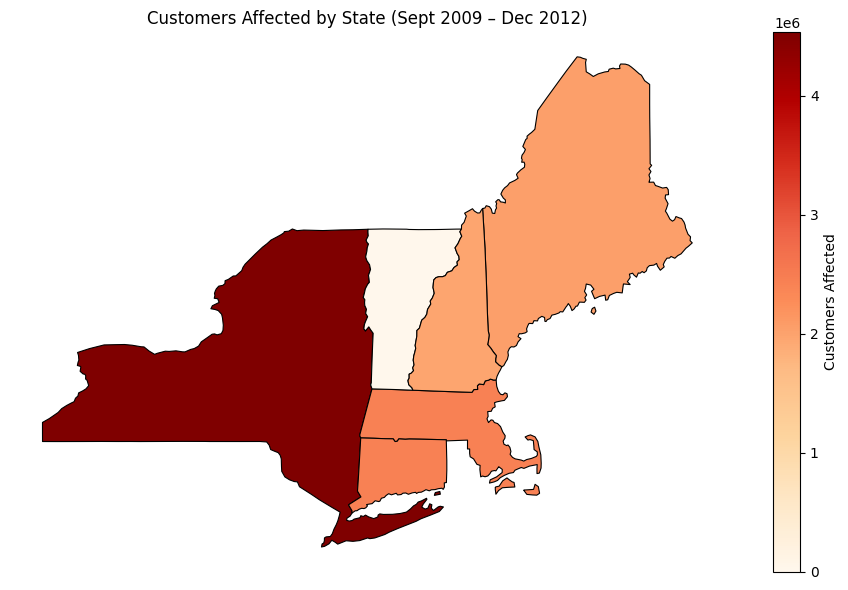

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# df = pd.read_csv('outages.csv', parse_dates=['Outage Start', 'Outage End'])

start_date = pd.Timestamp('2009-09-01')
end_date   = pd.Timestamp('2012-12-31')
date_mask  = (df['Outage Start'] >= start_date) & (df['Outage End'] <= end_date)

target_states = ['MA','ME','NH','NY','VT','CT']
df_states = (
    df[date_mask]
      .assign(StateCode=df['State'].str.replace(';',' ').str.split())
      .explode('StateCode')
      .query("StateCode in @target_states")
)


agg = (df_states
       .groupby('StateCode', as_index=False)
       ['Number of Customers Affected']
       .sum()
       .rename(columns={'Number of Customers Affected':'TotalAffected'}))
# path_shp = r"G/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/cb_2020_us_state_20m.shp"
states_gdf = gpd.read_file(r"/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/cb_2020_us_state_20m.shp")
# states_gdf = gpd.read_file('path_to_shapefile.shp')
states_gdf = states_gdf[states_gdf['STUSPS'].isin(target_states)]
map_gdf = states_gdf.merge(agg, left_on='STUSPS', right_on='StateCode', how='left').fillna(0)

fig, ax = plt.subplots(figsize=(10,6))
map_gdf.plot(
    column='TotalAffected',
    cmap='OrRd',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Customers Affected"},
    ax=ax
)
ax.set_title('Customers Affected by State (Sept 2009 – Dec 2012)')
ax.axis('off')
plt.tight_layout()
plt.savefig(r"/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/outage_impact_customers.png", dpi=600)
plt.show()

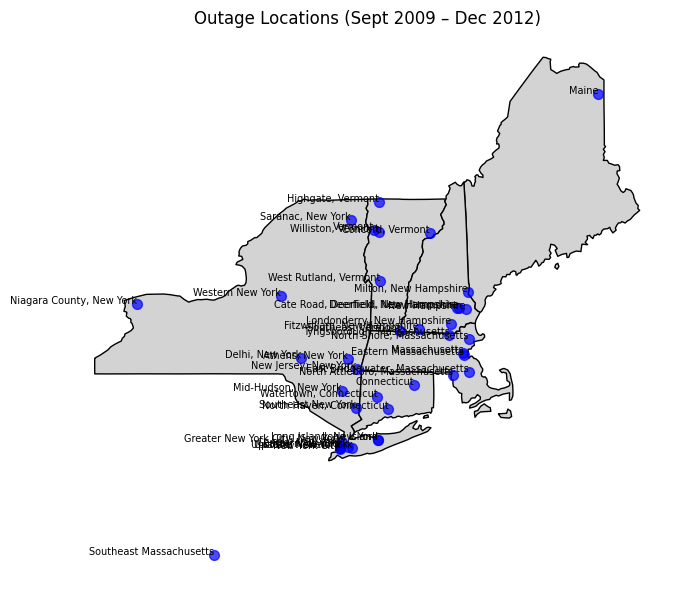

In [ ]:
from geopy.geocoders import Nominatim
import geopandas as gpd
import pandas as pd
import time

# — assume df_states already filtered and loaded —

# 1) Unique areas
areas = df_states[['Geographic Areas','StateCode']].drop_duplicates().reset_index(drop=True)

# 2) Geocode (with simple cache)
geolocator = Nominatim(user_agent="outage_mapper", timeout=10)
_cache = {}
def geocode_place(place, state):
    key = f"{place}|{state}"
    if key in _cache:
        return _cache[key]
    query = f"{place}, {state}, USA"
    for _ in range(3):
        try:
            loc = geolocator.geocode(query)
            if loc:
                coords = (loc.latitude, loc.longitude)
                _cache[key] = coords
                return coords
        except:
            time.sleep(1)
    return (None, None)

# 3) Apply geocoding
areas[['lat','lon']] = areas.apply(
    lambda row: geocode_place(row['Geographic Areas'], row['StateCode']),
    axis=1,
    result_type='expand'
)

# 4) Drop failures and reset index
areas_clean = areas.dropna(subset=['lat','lon']).reset_index(drop=True)

# 5) Build geometry from the cleaned DataFrame
geometry = gpd.points_from_xy(areas_clean.lon, areas_clean.lat)
points_gdf = gpd.GeoDataFrame(areas_clean, geometry=geometry, crs="EPSG:4326")

# 6) Plot on top of your state map:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))

# plot your states base (assuming you already have states_gdf)
states_gdf.plot(ax=ax, color='lightgray', edgecolor='black')

# plot points
points_gdf.plot(ax=ax, marker='o', markersize=50, alpha=0.7, color='blue')

# label each point
for _, pt in points_gdf.iterrows():
    ax.text(
        pt.geometry.x, pt.geometry.y,
        pt['Geographic Areas'],
        fontsize=7, ha='right'
    )

ax.set_title('Outage Locations (Sept 2009 – Dec 2012)')
ax.axis('off')
plt.tight_layout()
plt.savefig("outage_locations.png", dpi=600)
plt.show()


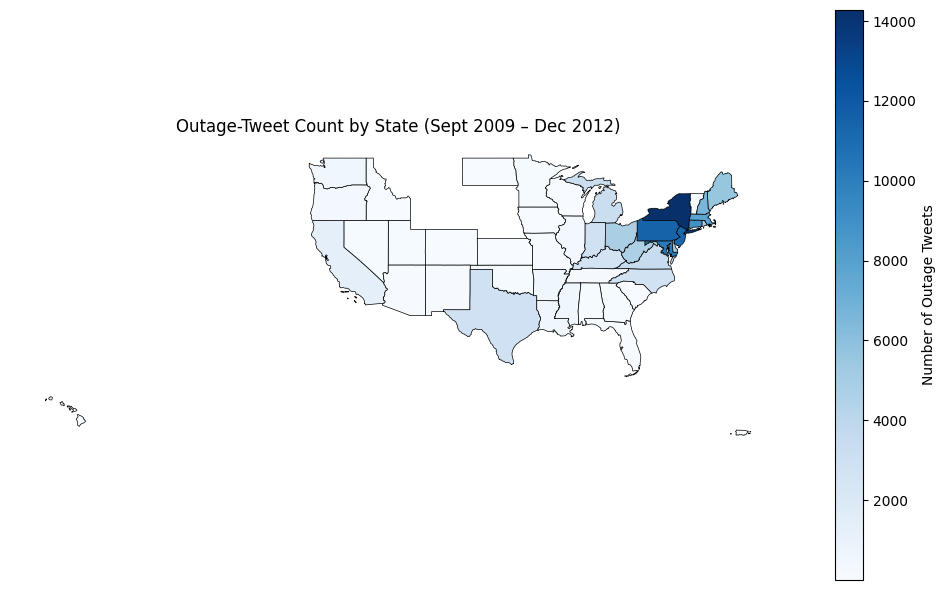

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

file_path = r"/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/combined_tweets_outages.csv"
df2 = pd.read_csv(
    file_path,
    parse_dates=['timestamp']
)


start_date = pd.Timestamp('2009-09-01')
end_date   = pd.Timestamp('2012-12-31')
df2 = df2[(df2['timestamp'] >= start_date) & (df2['timestamp'] <= end_date)]
df2 = df2[df2['outage'] == 1]
df2_states = (
    df2
    .assign(StateCode=df2['outage_state'].str.split())
    .explode('StateCode')
)
agg2 = (
    df2_states
    .groupby('StateCode', as_index=False)
    .size()
    .rename(columns={'size':'OutageTweetCount'})
)
# shp_path = 'path_to/cb_2020_us_state_20m.shp'
# states_gdf = gpd.read_file(shp_path)
states_gdf = gpd.read_file(r"/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/cb_2020_us_state_20m.shp")
states_gdf = states_gdf[states_gdf['STUSPS'].isin(agg2['StateCode'])]
map2 = states_gdf.merge(
    agg2,
    left_on='STUSPS',
    right_on='StateCode',
    how='left'
).fillna(0)
fig, ax = plt.subplots(figsize=(10, 6))
map2.plot(
    column='OutageTweetCount',
    cmap='Blues',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': "Number of Outage Tweets"},
    ax=ax
)
ax.set_title('Outage-Tweet Count by State (Sept 2009 – Dec 2012)')
ax.axis('off')
plt.tight_layout()
plt.savefig(r"/content/drive/MyDrive/WVU_academic/EE-593A/project/input_files/outage_by_state.png", dpi=600)
plt.show()


In [ ]:
pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 134.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.6 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import re
import plotly.express as px

st.set_page_config(page_title="Location & Cause Detector", layout="wide")

STATE_CODES = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY","DC"
]

try:
    import transformers  # noqa: F401
    HAS_TRANSFORMERS = True
except ImportError:
    HAS_TRANSFORMERS = False

@st.cache_resource
def load_outage_model():
    """
    Lazily load a zero-shot classification pipeline for outage detection.
    """
    if not HAS_TRANSFORMERS:
        return None
    from transformers import pipeline
    with st.spinner("Loading outage detection model..."):
        return pipeline(
            "zero-shot-classification",
            model="facebook/bart-large-mnli"
        )

@st.cache_resource
def load_cause_model():
    """
    Lazily load the BERT classification pipeline for cause detection.
    """
    if not HAS_TRANSFORMERS:
        return None
    from transformers import pipeline
    with st.spinner("Loading cause classification model..."):
        return pipeline(
            "text-classification",
            model="bert-base-uncased",
            tokenizer="bert-base-uncased"
        )


def is_outage_related(text: str, outage_model) -> bool:
    """
    Determine if the text is related to a power outage using zero-shot or keyword fallback.
    """
    lower = text.lower()
    if outage_model:
        with st.spinner("Checking outage relevance..."):
            result = outage_model(
                text,
                candidate_labels=["power outage", "other"],
                multi_label=False
            )
            label = result['labels'][0]
            score = result['scores'][0]
            return label == "power outage" and score > 0.5
    return any(k in lower for k in ["outage", "blackout", "power cut", "power loss", "power outage"])


def extract_states(text: str) -> list[str]:
    """
    Find all state codes in text using regex word boundaries.
    """
    return sorted({code for code in STATE_CODES if re.search(rf"\b{code}\b", text)})


def classify_cause(text: str, classifier) -> tuple[list[str], bool]:
    """
    Detect one or more causes by keyword matching or BERT fallback.
    Returns a list of cause labels and a bool indicating if BERT was used.
    """
    lower = text.lower()
    keywords = ["fire", "storm", "flood", "tornado", "earthquake", "vandalism", "damage", "winter storm"]
    found = [kw.capitalize() for kw in keywords if kw in lower]
    if found:
        return found, False

    if classifier:
        with st.spinner("Classifying cause with BERT..."):
            results = classifier(text, top_k=3)
            labels = [res['label'].replace("LABEL_", "").capitalize() for res in results]
            return labels, True

    return [], False


def plot_state_map(states: list[str]):
    """
    Display a U.S. map outlining detected states.
    """
    if not states:
        st.info("No states detected to display on map.")
        return
    values = [1] * len(states)
    fig = px.choropleth(
        locations=states,
        locationmode="USA-states",
        color=values,
        scope="usa",
        color_continuous_scale=[(0, "lightgray"), (1, "blue")],
        labels={'color': 'Detected'}
    )
    fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0}, coloraxis_showscale=False)
    st.plotly_chart(fig, use_container_width=True)


def main():
    st.image("logo.png", width=150)
    st.title("Power Outage Location & Cause Detector")
    st.write(
        """
        Social Media Post:
        """
    )

    with st.sidebar:
        st.header("Setup & Info")
        st.markdown(
            """
            - Enable BERT: `pip install transformers torch`
            - For map: `pip install plotly`
            """
        )
        st.markdown(f"**Transformers Installed:** {'Yes' if HAS_TRANSFORMERS else 'No'}")

    with st.form(key="input_form"):
        text_input = st.text_area("Tweet", height=150)
        analyze_btn = st.form_submit_button("Analyze")

    if analyze_btn:
        if not text_input.strip():
            st.warning("Please type some text before analyzing.")
            return

        # Outage relevance check
        outage_model = load_outage_model()
        outage_ok = is_outage_related(text_input, outage_model)
        if not outage_ok:
            st.warning("Text is not related to a power outage. Skipping analysis.")
            return

        # Extract states & causes
        classifier = load_cause_model()
        states = extract_states(text_input)
        causes, bert_used = classify_cause(text_input, classifier)

        steps = [
            ("Outage relevance check", True),
            ("State extraction", bool(states)),
            ("Cause classification", True),
            ("Map rendering", bool(states))
        ]
        st.subheader("Analysis Steps Completed:")
        for desc, done in steps:
            mark = ":white_check_mark:" if done else ":white_large_square:"
            st.markdown(f"{mark} {desc}")
        st.subheader("Results:")
        st.markdown(f"**Outage Location:** {', '.join(states) if states else 'None'}")
        causes_display = ", ".join(causes) if causes else "None"
        st.markdown(f"**Caused By:** {causes_display}")

        st.markdown("Outage Map:")
        plot_state_map(states)

if __name__ == "__main__":
    main()

2025-04-30 01:00:20.156 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-30 01:00:20.160 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-30 01:00:20.204 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-30 01:00:20.254 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-04-30 01:00:20.254 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-30 01:00:20.255 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-30 01:00:20.256 Thread 'MainThread'

<ipython-input-6-f30ca91f2840>:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  states['centroid'] = states.geometry.centroid


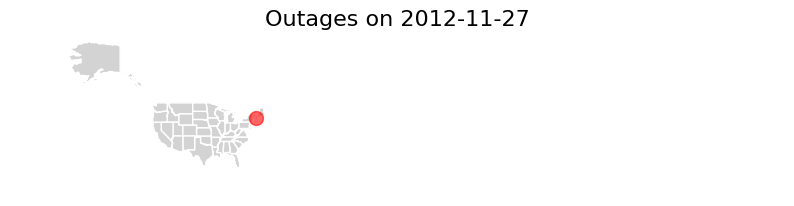

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

result = pd.read_csv("doe_monthlytweets_with_outage_updated.csv")
df = result.copy()
df['Event Date'] = pd.to_datetime(df['Event Date'], format='%m/%d/%Y')

states = gpd.read_file("cb_2020_us_state_20m.shp")
states['centroid'] = states.geometry.centroid
centroids = states.set_index('STUSPS')['centroid']

dates = df['Event Date'].drop_duplicates().sort_values().reset_index(drop=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_axis_off()

def update(frame):
    ax.clear()
    ax.set_axis_off()
    states.plot(ax=ax, color='lightgrey', edgecolor='white')
    current_date = dates[frame]
    todays = df[df['Event Date'] == current_date]
    pts = todays['State'].map(centroids)
    xs = [pt.x for pt in pts]
    ys = [pt.y for pt in pts]
    sizes = todays['Outage_status'] * 100
    ax.scatter(xs, ys, s=sizes, alpha=0.6, color='red')
    ax.set_title(f"Outages on {current_date.strftime('%Y-%m-%d')}", fontsize=16)

anim = FuncAnimation(fig, update, frames=len(dates), interval=1000, repeat=False)
anim.save("us_outages.gif", writer="pillow", fps=1)
plt.show()
